Number of cameras: 18
Cameras: ['bartlett', 'delta_junction', 'glees', 'hyytiala', 'kenttarova', 'lacclair', 'marcell_MN', 'old_jack_pine', 'oregon_yp', 'queens', 'sodankyla_full', 'tammela', 'torgnon', 'underc', 'underhill', 'varrio', 'willowcreek', 'wslcreek']

=== Bootstrap 1/1000 ===
Chosen filter -> Eg_strong/Eg_weak >= 1.22, data_quantity >= 15 | CV acc=0.9371, CV bin acc=0.9748, n_rows(dedup)=556
OOB cameras: ['kenttarova', 'oregon_yp', 'queens', 'torgnon', 'underc', 'varrio', 'wslcreek']
OOB n=330
OOB multiclass accuracy=0.9515
OOB binary accuracy 0 vs {1,2}=0.9970
4.05s

=== Bootstrap 2/1000 ===
Chosen filter -> Eg_strong/Eg_weak >= 1.05, data_quantity >= 16 | CV acc=0.9618, CV bin acc=0.9904, n_rows(dedup)=628
OOB cameras: ['bartlett', 'lacclair', 'old_jack_pine', 'sodankyla_full', 'torgnon', 'willowcreek']
OOB n=268
OOB multiclass accuracy=0.8918
OOB binary accuracy 0 vs {1,2}=0.9366
5.12s

=== Bootstrap 3/1000 ===
Chosen filter -> Eg_strong/Eg_weak >= 1.08, data_quantity >=

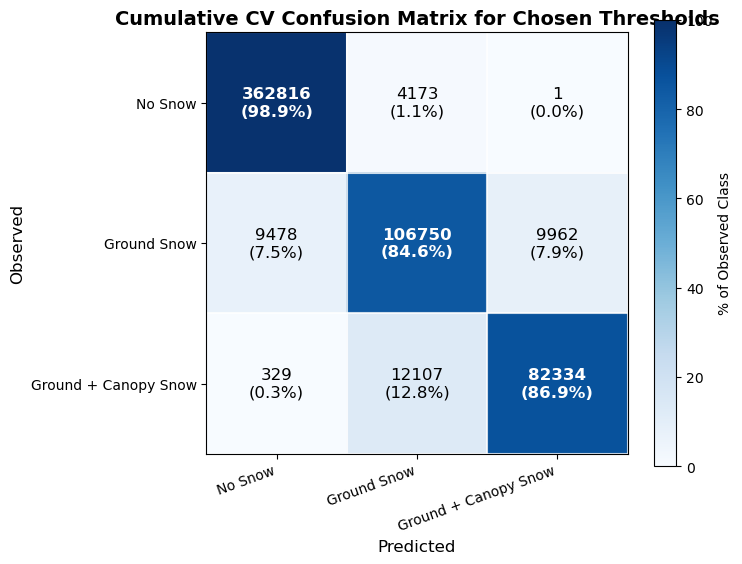

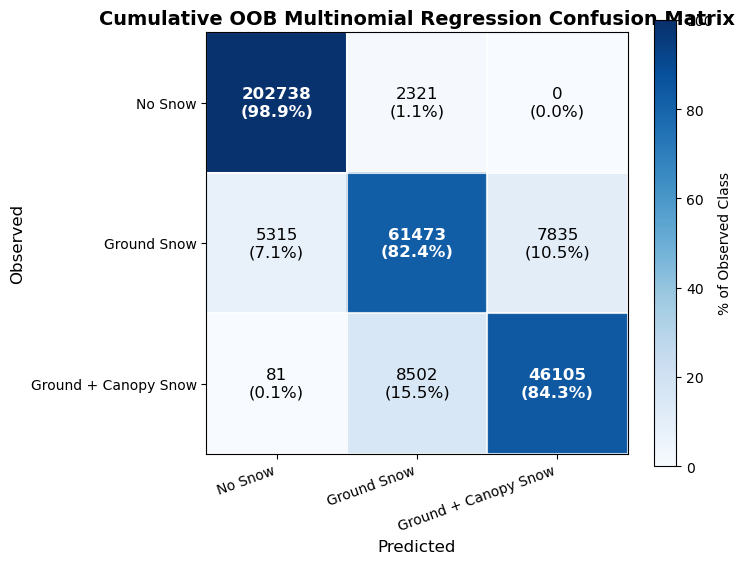


CUMULATIVE OOB CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             No Snow       0.97      0.99      0.98    205059
         Ground Snow       0.85      0.82      0.84     74623
Ground + Canopy Snow       0.85      0.84      0.85     54688

            accuracy                           0.93    334370
           macro avg       0.89      0.89      0.89    334370
        weighted avg       0.93      0.93      0.93    334370



In [1]:
from scripts.imports import *

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ===========================================================
# LOAD AND GROUP DATA
# ===========================================================

df = pd.read_pickle(
    'dataset_lcforest_noLOF_bin30_th3_80m_1kmsmallbox_noprior_ta_wc1_v7.pkl'
)

df['Eg_strong'] = np.where(
    (df['beam_str'] == 'strong') & (df['outlier'] == 1),
    df['Eg'],
    np.nan
)
df['Ev_strong'] = np.where(
    (df['beam_str'] == 'strong') & (df['outlier'] == 1),
    df['Ev'],
    np.nan
)
df['Eg_weak'] = np.where(
    (df['beam_str'] == 'weak') & (df['outlier'] == 1),
    df['Eg'],
    np.nan
)
df['Ev_weak'] = np.where(
    (df['beam_str'] == 'weak') & (df['outlier'] == 1),
    df['Ev'],
    np.nan
)

df['forest_type'] = np.where(df['segment_landcover'] < 119, 'closed', 'open')

df_grouped = df.groupby(['camera', 'date', 'lat', 'lon']).agg({
    'pvpg': 'mean',
    'pv': 'max',
    'pg': 'max',
    'Eg_strong': 'median',
    'Ev_strong': 'median',
    'Eg_weak': 'median',
    'Ev_weak': 'median',
    'data_quantity': 'max',
    'snr': 'mean',
    'FSC': 'mean',
    'TreeSnow': 'mean',
    'layer_flag': 'mean',
    'file_index': 'mean',
    'msw_flag': 'mean',
    'pv_ratio_mean': 'mean',
    'pv_ratio_max': 'mean',
    'forest_type': lambda x: pd.Series.mode(x).iloc[0],
}).reset_index()

df_grouped = df_grouped[df_grouped['Eg_strong'] >= 0].copy()
df_grouped['JointSnow'] = df_grouped['FSC'] + df_grouped['TreeSnow']


# ===========================================================
# CONFIG
# ===========================================================

N_BOOT = 1000
N_SPLITS_CV = 5
TOL_NEAR = 0.003
RNG = np.random.RandomState(42)

FEATURES = ['Eg_strong', 'Ev_strong']
TARGET_COL = 'JointSnowRounded'

RATIO_GRID = np.round(np.arange(1.05, 1.30 + 1e-9, 0.01), 2)
DQ_GRID = np.arange(9, 18)

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = [
    "No Snow",
    "Ground Snow",
    "Ground + Canopy Snow"
]


# ===========================================================
# FILTERING AND MULTINOMIAL DATASET HELPERS
# ===========================================================

def base_conditions_multinomial(df):
    """
    Base conditions for the multinomial regression.

    This uses only binary endpoint observations:
        FSC approximately 0 or 1
        TreeSnow exactly 0 or 1

    JointSnow = FSC + TreeSnow gives classes:
        0 = no snow
        1 = ground snow
        2 = ground + canopy snow
    """

    return (
        ((df['FSC'] <= 0.005) | (df['FSC'] >= 0.995)) &
        ((df['TreeSnow'] == 0) | (df['TreeSnow'] == 1)) &
        np.isfinite(df['Eg_strong']) &
        np.isfinite(df['Ev_strong']) &
        np.isfinite(df['Eg_weak']) &
        (df['Eg_weak'] > 0) &
        np.isfinite(df['data_quantity'])
    )


def apply_thresholds_for_multinomial(df, ratio_thresh, dq_thresh):
    """
    Applies base multinomial conditions plus the threshold pair being tested.
    """

    cond = (
        base_conditions_multinomial(df) &
        ((df['Eg_strong'] / df['Eg_weak']) >= ratio_thresh) &
        (df['data_quantity'] >= dq_thresh)
    )

    out = df.loc[cond].copy()

    out['JointSnow'] = out['FSC'] + out['TreeSnow']
    out['JointSnowRounded'] = np.round(out['JointSnow']).astype(int)

    out = out[out['JointSnowRounded'].isin(CLASS_LABELS)].copy()

    return out


# ===========================================================
# CV HELPERS FOR THRESHOLD SEARCH
# ===========================================================

def assign_folds_by_camera(df, n_splits=5):
    """
    Round-robin assignment by camera frequency.
    Returns fold indices aligned with df rows.
    """

    counts = df['camera'].value_counts()
    cams_sorted = counts.index.tolist()
    cam2fold = {
        cam: i % n_splits
        for i, cam in enumerate(cams_sorted)
    }

    return df['camera'].map(cam2fold).to_numpy()


def cv_multinomial_metrics(df, features=FEATURES, n_splits=N_SPLITS_CV):
    """
    Camera-grouped CV for the 3-class multinomial target.

    Returns:
        multiclass accuracy
        3x3 confusion matrix
        binary accuracy with classes {1,2} collapsed to 1
    """

    if len(df) == 0:
        return np.nan, None, np.nan

    if df[TARGET_COL].nunique() < 2:
        return np.nan, None, np.nan

    n_unique_cams = df['camera'].nunique()

    if n_unique_cams < 2:
        return np.nan, None, np.nan

    n_splits_eff = max(2, min(n_splits, n_unique_cams))

    grp = assign_folds_by_camera(df, n_splits_eff)

    X = df.loc[:, list(features)].to_numpy()
    y = df[TARGET_COL].to_numpy()

    valid = np.isfinite(X).all(axis=1) & np.isfinite(y)

    X = X[valid]
    y = y[valid]
    grp = grp[valid]

    if len(y) == 0:
        return np.nan, None, np.nan

    if np.unique(y).size < 2:
        return np.nan, None, np.nan

    all_true = []
    all_pred = []

    for f in range(n_splits_eff):

        test_mask = grp == f
        train_mask = ~test_mask

        if not np.any(test_mask) or not np.any(train_mask):
            continue

        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test = X[test_mask]
        y_test = y[test_mask]

        if np.unique(y_train).size < 2:
            continue

        model = LogisticRegression(
            solver='lbfgs',
            max_iter=1000,
            random_state=0
        )

        model.fit(X_train, y_train)

        y_hat = model.predict(X_test)

        all_true.extend(y_test.tolist())
        all_pred.extend(y_hat.tolist())

    if len(all_true) == 0:
        return np.nan, None, np.nan

    all_true = np.asarray(all_true)
    all_pred = np.asarray(all_pred)

    acc = accuracy_score(all_true, all_pred)

    cm = confusion_matrix(
        all_true,
        all_pred,
        labels=CLASS_LABELS
    )

    y_true_bin = (all_true >= 1).astype(int)
    y_pred_bin = (all_pred >= 1).astype(int)

    bin_acc = accuracy_score(y_true_bin, y_pred_bin)

    return acc, cm, bin_acc


def grid_search_thresholds(dedup_train, ratio_grid, dq_grid):
    """
    Searches over Eg_strong/Eg_weak and data_quantity thresholds.

    This is done on the deduplicated bootstrap training cameras,
    as in your original code.
    """

    rows = []

    for ratio_thresh in ratio_grid:

        for dq_thresh in dq_grid:

            df_f = apply_thresholds_for_multinomial(
                dedup_train,
                ratio_thresh,
                dq_thresh
            )

            acc, cm, bin_acc = cv_multinomial_metrics(df_f)

            rows.append({
                'ratio': float(ratio_thresh),
                'dq': int(dq_thresh),
                'accuracy': acc,
                'bin_acc': bin_acc,
                'n_rows': int(len(df_f)),
                'conf_mat': cm
            })

    res = pd.DataFrame(rows)
    res = res.dropna(subset=['accuracy']).reset_index(drop=True)

    return res


def choose_best_thresholds(res, tol=TOL_NEAR):
    """
    Choose among threshold combinations within tol of the best CV accuracy.

    Priority:
        1. largest retained n_rows
        2. higher accuracy
        3. smaller ratio threshold
        4. smaller data_quantity threshold
    """

    if res.empty:
        return None, pd.DataFrame(columns=res.columns)

    best = res['accuracy'].max()

    near = res[res['accuracy'] >= best - tol].copy()

    near = near.sort_values(
        ['n_rows', 'accuracy', 'ratio', 'dq'],
        ascending=[False, False, True, True]
    ).reset_index(drop=True)

    return near.iloc[0].to_dict(), near


# ===========================================================
# FINAL MULTINOMIAL MODEL HELPERS
# ===========================================================

def fit_multinomial_model(train_df):
    """
    Fits final multinomial logistic regression after chosen thresholds.
    """

    X_train = train_df[FEATURES].to_numpy()
    y_train = train_df[TARGET_COL].to_numpy()

    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=0
    )

    model.fit(X_train, y_train)

    return model


def predict_multinomial(model, test_df):
    X_test = test_df[FEATURES].to_numpy()
    return model.predict(X_test)


def binary_accuracy_from_multiclass(y_true, y_pred):
    """
    Collapses classes {1, 2} into snow-present and compares against class 0.
    """

    y_true_bin = (np.asarray(y_true) >= 1).astype(int)
    y_pred_bin = (np.asarray(y_pred) >= 1).astype(int)

    return accuracy_score(y_true_bin, y_pred_bin)


# ===========================================================
# BOOTSTRAP LOOP
# ===========================================================

all_cameras = sorted(df_grouped['camera'].unique())

print(f"Number of cameras: {len(all_cameras)}")
print(f"Cameras: {all_cameras}")

bootstrap_rows = []

all_oob_y_true = []
all_oob_y_pred = []

cumulative_cv_conf_mat = np.zeros((3, 3), dtype=int)
cumulative_oob_conf_mat = np.zeros((3, 3), dtype=int)

for b in range(N_BOOT):

    start = time.time()

    sampled_cams = RNG.choice(
        all_cameras,
        size=len(all_cameras),
        replace=True
    )

    sampled_unique = sorted(set(sampled_cams))
    oob_cams = sorted(set(all_cameras) - set(sampled_unique))

    # Duplicated bootstrap training set:
    # if a camera is drawn multiple times, its rows are included multiple times.
    boot_concat = pd.concat(
        [
            df_grouped[df_grouped['camera'] == cam]
            for cam in sampled_cams
        ],
        ignore_index=True
    )

    # Deduplicated training set for threshold search
    dedup_train = df_grouped[
        df_grouped['camera'].isin(sampled_unique)
    ].copy()

    print(f"\n=== Bootstrap {b + 1}/{N_BOOT} ===")

    # -------------------------------------------------------
    # 1. Search thresholds on deduplicated bootstrap train set
    # -------------------------------------------------------

    res = grid_search_thresholds(
        dedup_train,
        RATIO_GRID,
        DQ_GRID
    )

    chosen, near = choose_best_thresholds(
        res,
        tol=TOL_NEAR
    )

    if chosen is None:

        print("No valid threshold combination produced a trainable dataset.")

        bootstrap_rows.append({
            'bootstrap': b + 1,
            'ratio': np.nan,
            'dq': np.nan,
            'n_rows_search': 0,
            'n_rows_boot_train': 0,
            'n_rows_oob': 0,
            'n_oob_cameras': len(oob_cams),
            'cv_acc': np.nan,
            'cv_bin_acc': np.nan,
            'oob_acc': np.nan,
            'oob_bin_acc': np.nan
        })

        continue

    print(
        f"Chosen filter -> "
        f"Eg_strong/Eg_weak >= {chosen['ratio']:.2f}, "
        f"data_quantity >= {int(chosen['dq'])} | "
        f"CV acc={chosen['accuracy']:.4f}, "
        f"CV bin acc={chosen['bin_acc']:.4f}, "
        f"n_rows(dedup)={int(chosen['n_rows'])}"
    )

    if isinstance(chosen.get('conf_mat', None), np.ndarray):
        cumulative_cv_conf_mat += chosen['conf_mat'].astype(int)

    # -------------------------------------------------------
    # 2. Apply chosen thresholds to duplicated bootstrap train
    # -------------------------------------------------------

    boot_train = apply_thresholds_for_multinomial(
        boot_concat,
        chosen['ratio'],
        int(chosen['dq'])
    )

    # -------------------------------------------------------
    # 3. Apply chosen thresholds to OOB cameras
    # -------------------------------------------------------

    oob_df = df_grouped[
        df_grouped['camera'].isin(oob_cams)
    ].copy()

    oob_df = apply_thresholds_for_multinomial(
        oob_df,
        chosen['ratio'],
        int(chosen['dq'])
    )

    if len(boot_train) == 0:

        print("Bootstrapped training set empty after chosen thresholds; skipping.")

        bootstrap_rows.append({
            'bootstrap': b + 1,
            'ratio': float(chosen['ratio']),
            'dq': int(chosen['dq']),
            'n_rows_search': int(chosen['n_rows']),
            'n_rows_boot_train': 0,
            'n_rows_oob': len(oob_df),
            'n_oob_cameras': len(oob_cams),
            'cv_acc': float(chosen['accuracy']),
            'cv_bin_acc': float(chosen['bin_acc']),
            'oob_acc': np.nan,
            'oob_bin_acc': np.nan
        })

        continue

    if boot_train[TARGET_COL].nunique() < 2:

        print("Bootstrapped training set has fewer than 2 classes; skipping.")

        bootstrap_rows.append({
            'bootstrap': b + 1,
            'ratio': float(chosen['ratio']),
            'dq': int(chosen['dq']),
            'n_rows_search': int(chosen['n_rows']),
            'n_rows_boot_train': len(boot_train),
            'n_rows_oob': len(oob_df),
            'n_oob_cameras': len(oob_cams),
            'cv_acc': float(chosen['accuracy']),
            'cv_bin_acc': float(chosen['bin_acc']),
            'oob_acc': np.nan,
            'oob_bin_acc': np.nan
        })

        continue

    if len(oob_df) == 0:

        print("No OOB rows after chosen thresholds.")

        bootstrap_rows.append({
            'bootstrap': b + 1,
            'ratio': float(chosen['ratio']),
            'dq': int(chosen['dq']),
            'n_rows_search': int(chosen['n_rows']),
            'n_rows_boot_train': len(boot_train),
            'n_rows_oob': 0,
            'n_oob_cameras': len(oob_cams),
            'cv_acc': float(chosen['accuracy']),
            'cv_bin_acc': float(chosen['bin_acc']),
            'oob_acc': np.nan,
            'oob_bin_acc': np.nan
        })

        continue

    # -------------------------------------------------------
    # 4. Fit multinomial regression and predict OOB cameras
    # -------------------------------------------------------

    model = fit_multinomial_model(boot_train)

    y_true = oob_df[TARGET_COL].to_numpy()
    y_pred = predict_multinomial(model, oob_df)

    oob_acc = accuracy_score(y_true, y_pred)
    oob_bin_acc = binary_accuracy_from_multiclass(y_true, y_pred)

    oob_cm = confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_LABELS
    )

    cumulative_oob_conf_mat += oob_cm

    all_oob_y_true.append(y_true.copy())
    all_oob_y_pred.append(y_pred.copy())

    print(f"OOB cameras: {oob_cams if len(oob_cams) else 'none'}")
    print(f"OOB n={len(oob_df)}")
    print(f"OOB multiclass accuracy={oob_acc:.4f}")
    print(f"OOB binary accuracy 0 vs {{1,2}}={oob_bin_acc:.4f}")

    bootstrap_rows.append({
        'bootstrap': b + 1,
        'ratio': float(chosen['ratio']),
        'dq': int(chosen['dq']),
        'n_rows_search': int(chosen['n_rows']),
        'n_rows_boot_train': int(len(boot_train)),
        'n_rows_oob': int(len(oob_df)),
        'n_oob_cameras': int(len(oob_cams)),
        'cv_acc': float(chosen['accuracy']),
        'cv_bin_acc': float(chosen['bin_acc']),
        'oob_acc': float(oob_acc),
        'oob_bin_acc': float(oob_bin_acc)
    })

    end = time.time()
    print(f"{round(end - start, 2)}s")


# ===========================================================
# SUMMARY TABLES
# ===========================================================

bootstrap_df = pd.DataFrame(bootstrap_rows)

print("\n====================")
print("BOOTSTRAP SUMMARY")
print("====================")

def mean_std(series):
    return f"{np.nanmean(series):.4f} � {np.nanstd(series):.4f}"


print("\nFilter choice frequency across bootstraps:")

freq = (
    bootstrap_df
    .dropna(subset=['ratio', 'dq'])
    .value_counts(subset=['ratio', 'dq'])
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(freq.to_string(index=False))


print("\nCV metrics from chosen thresholds:")
print("Multiclass accuracy: ", mean_std(bootstrap_df['cv_acc']))
print("Binary accuracy:     ", mean_std(bootstrap_df['cv_bin_acc']))


print("\nOOB metrics after final multinomial regression:")
print("Multiclass accuracy: ", mean_std(bootstrap_df['oob_acc']))
print("Binary accuracy:     ", mean_std(bootstrap_df['oob_bin_acc']))


print("\nOOB row/camera counts:")
print("Mean OOB rows:       ", f"{np.nanmean(bootstrap_df['n_rows_oob']):.1f}")
print("Mean OOB cameras:    ", f"{np.nanmean(bootstrap_df['n_oob_cameras']):.1f}")


print("\nBootstrap results:")
print(bootstrap_df.to_string(index=False))


# ===========================================================
# PLOT HELPER
# ===========================================================

def plot_confusion_matrix(cm_counts, title):
    """
    Plots row-normalized confusion matrix with counts and percentages.
    """

    cm = cm_counts.astype(float)

    row_sums = cm.sum(axis=1, keepdims=True)

    pct = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm),
        where=row_sums != 0
    ) * 100.0

    fig, ax = plt.subplots(figsize=(7.5, 6))

    im = ax.imshow(
        pct,
        cmap="Blues",
        vmin=0,
        vmax=100
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            count = int(cm[i, j])
            perc = pct[i, j]

            ax.text(
                j,
                i,
                f"{count}\n({perc:.1f}%)",
                ha="center",
                va="center",
                fontsize=12,
                color="white" if perc > 50 else "black",
                fontweight="bold" if perc > 50 else "normal"
            )

    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))

    ax.set_xticklabels(
        CLASS_NAMES,
        rotation=20,
        ha="right"
    )

    ax.set_yticklabels(CLASS_NAMES)

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Observed", fontsize=12)
    ax.set_title(title, fontsize=14, weight="bold")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("% of Observed Class", rotation=90)

    ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1.5,
        alpha=0.8
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    plt.tight_layout()
    plt.show()


# ===========================================================
# CONFUSION MATRICES
# ===========================================================

plot_confusion_matrix(
    cumulative_cv_conf_mat,
    "Cumulative CV Confusion Matrix for Chosen Thresholds"
)

plot_confusion_matrix(
    cumulative_oob_conf_mat,
    "Cumulative OOB Multinomial Regression Confusion Matrix"
)


# ===========================================================
# CUMULATIVE CLASSIFICATION REPORT
# ===========================================================

if len(all_oob_y_true) > 0:

    y_true_all = np.concatenate(all_oob_y_true)
    y_pred_all = np.concatenate(all_oob_y_pred)

    print("\n====================")
    print("CUMULATIVE OOB CLASSIFICATION REPORT")
    print("====================")

    print(
        classification_report(
            y_true_all,
            y_pred_all,
            labels=CLASS_LABELS,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

else:
    print("\nNo valid OOB predictions were produced.")

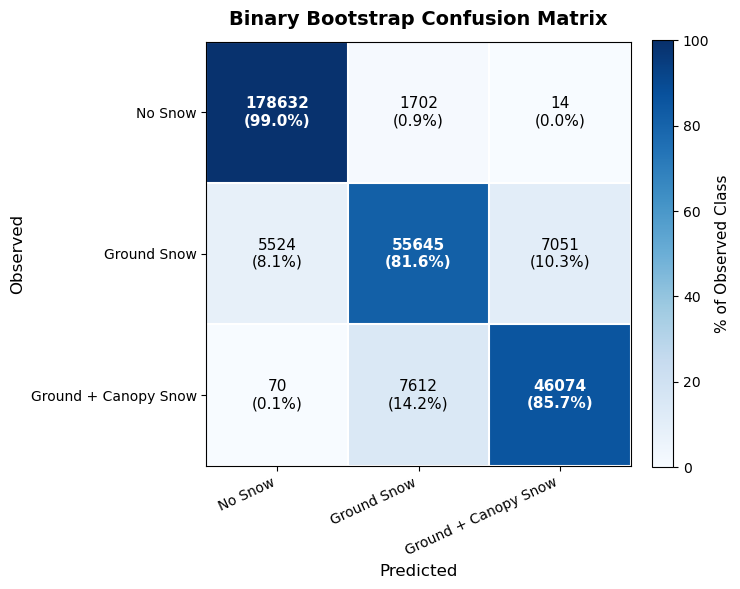

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your existing confusion matrix variable if needed
cm = np.array([
    [178632, 1702,    14],
    [  5524, 55645, 7051],
    [    70,  7612, 46074]
])

classes = ["No Snow", "Ground Snow", "Ground + Canopy Snow"]

# Row-normalised percentages for colour and annotation
row_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7.2, 5.8), constrained_layout=True)

im = ax.imshow(row_pct, cmap="Blues", vmin=0, vmax=100)

ax.set_title("ICESat-2 Bootstrapped Binary Classification Accuracy",
             fontsize=14, weight="bold", pad=12)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Observed", fontsize=12)

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=25, ha="right", fontsize=10)
ax.set_yticklabels(classes, fontsize=10)

# Cell annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        colour = "white" if row_pct[i, j] > 50 else "black"
        weight = "bold" if i == j else "normal"
        ax.text(
            j, i,
            f"{cm[i, j]}\n({row_pct[i, j]:.1f}%)",
            ha="center", va="center",
            color=colour,
            fontsize=11,
            weight=weight
        )

# Optional subtle grid between cells
ax.set_xticks(np.arange(-0.5, len(classes), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(classes), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("% of Observed Class", fontsize=11)

plt.show()

In [1]:
from scripts.imports import *

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ===========================================================
# LOAD AND GROUP DATA
# ===========================================================

df = pd.read_pickle(
    'dataset_lcforest_noLOF_bin15_th3_80m_1kmsmallbox_noprior_ta_wc1_v7.pkl'
)

df['Eg_strong'] = np.where(
    (df['beam_str'] == 'strong') & (df['outlier'] == 1),
    df['Eg'],
    np.nan
)
df['Ev_strong'] = np.where(
    (df['beam_str'] == 'strong') & (df['outlier'] == 1),
    df['Ev'],
    np.nan
)
df['Eg_weak'] = np.where(
    (df['beam_str'] == 'weak') & (df['outlier'] == 1),
    df['Eg'],
    np.nan
)
df['Ev_weak'] = np.where(
    (df['beam_str'] == 'weak') & (df['outlier'] == 1),
    df['Ev'],
    np.nan
)

df['forest_type'] = np.where(df['segment_landcover'] < 119, 'closed', 'open')

df_grouped = df.groupby(['camera', 'date', 'lat', 'lon']).agg({
    'pvpg': 'mean',
    'pv': 'max',
    'pg': 'max',
    'Eg_strong': 'median',
    'Ev_strong': 'median',
    'Eg_weak': 'median',
    'Ev_weak': 'median',
    'data_quantity': 'max',
    'snr': 'mean',
    'FSC': 'mean',
    'TreeSnow': 'mean',
    'layer_flag': 'mean',
    'file_index': 'mean',
    'msw_flag': 'mean',
    'pv_ratio_mean': 'mean',
    'pv_ratio_max': 'mean',
    'forest_type': lambda x: pd.Series.mode(x).iloc[0],
}).reset_index()

df_grouped = df_grouped[df_grouped['Eg_strong'] >= 0].copy()
df_grouped['JointSnow'] = df_grouped['FSC'] + df_grouped['TreeSnow']

frac_data = df_grouped[((df_grouped['FSC'] >= 0.00)&(df_grouped['FSC'] <= 1.00))
    &(df_grouped['Eg_strong'] < 16)&(df_grouped['Ev_strong'] < 16)#&(df_grouped['pvpg'] <= 7.5)
# &
    # &(df_grouped['pv_ratio_mean'] >= 1.2)
    &(df_grouped['Eg_strong']/df_grouped['Eg_weak'] >= 1.05)
    # &((df_grouped['layer_flag'] <= 0.6)&(df_grouped['msw_flag'] <= 3.0))
    &(df_grouped['data_quantity'] >= 18)]
frac_data['JointSnowBinary'] = frac_data['JointSnow'].apply(lambda x: 1 if x >= 1 else x)

/tmp/ipykernel_962137/3331296749.py:77: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frac_data['JointSnowBinary'] = frac_data['JointSnow'].apply(lambda x: 1 if x >= 1 else x)


In [24]:
frac_data[(frac_data['camera']=='oregon_yp')&(frac_data['FSC']==0)&(frac_data['Eg_strong']>1.6)]#&(frac_data['Eg_strong']>1.8)].iloc[1]#&(frac_data['FSC']<1)]

,camera,date,lat,lon,pvpg,pv,pg,Eg_strong,Ev_strong,Eg_weak,...,FSC,TreeSnow,layer_flag,file_index,msw_flag,pv_ratio_mean,pv_ratio_max,forest_type,JointSnow,JointSnowBinary
957,oregon_yp,12/06/2023,44.319295,-121.594298,0.507002,1.380103,2.722086,1.656863,0.500000,0.428571,...,0.0,0.0,0.0,33.0,0.000000,1.384700,1.384700,open,0.0,0.0
990,oregon_yp,16/06/2021,44.310286,-121.559958,0.748108,1.759550,2.351999,1.611111,0.550000,0.654762,...,0.0,0.0,0.0,18.0,0.000000,1.599909,1.599909,open,0.0,0.0
1007,oregon_yp,17/06/2020,44.301277,-121.567964,0.620702,1.634961,2.634053,1.673203,0.555454,0.892045,...,0.0,0.0,0.0,11.0,0.000000,1.629056,1.629056,open,0.0,0.0
1016,oregon_yp,17/06/2020,44.346323,-121.614157,0.625531,1.788897,2.859805,1.647059,0.750000,0.550505,...,0.0,0.0,0.0,11.0,0.000000,1.876818,1.876818,closed,0.0,0.0
1017,oregon_yp,17/06/2020,44.346323,-121.573850,0.541678,1.588807,2.933123,1.609907,0.743034,0.773810,...,0.0,0.0,0.0,11.0,0.000000,1.682381,1.682381,closed,0.0,0.0
1086,oregon_yp,24/10/2019,44.328305,-121.581679,0.647921,1.690573,2.609225,1.717105,0.555556,0.857143,...,0.0,0.0,0.0,7.0,1.096774,1.792500,1.792500,open,0.0,0.0


In [6]:
frac_data['camera'].unique()

array(['bartlett', 'delta_junction', 'glees', 'hyytiala', 'kenttarova',
       'lacclair', 'marcell_MN', 'old_jack_pine', 'oregon_yp', 'queens',
       'sodankyla_full', 'tammela', 'torgnon', 'underc', 'underhill',
       'varrio', 'willowcreek', 'wslcreek'], dtype=object)

In [2]:
frac_data.columns

Index(['camera', 'date', 'lat', 'lon', 'pvpg', 'pv', 'pg', 'Eg_strong',
       'Ev_strong', 'Eg_weak', 'Ev_weak', 'data_quantity', 'snr', 'FSC',
       'TreeSnow', 'layer_flag', 'file_index', 'msw_flag', 'pv_ratio_mean',
       'pv_ratio_max', 'forest_type', 'JointSnow', 'JointSnowBinary'],
      dtype='object')

All filtered data: 1123


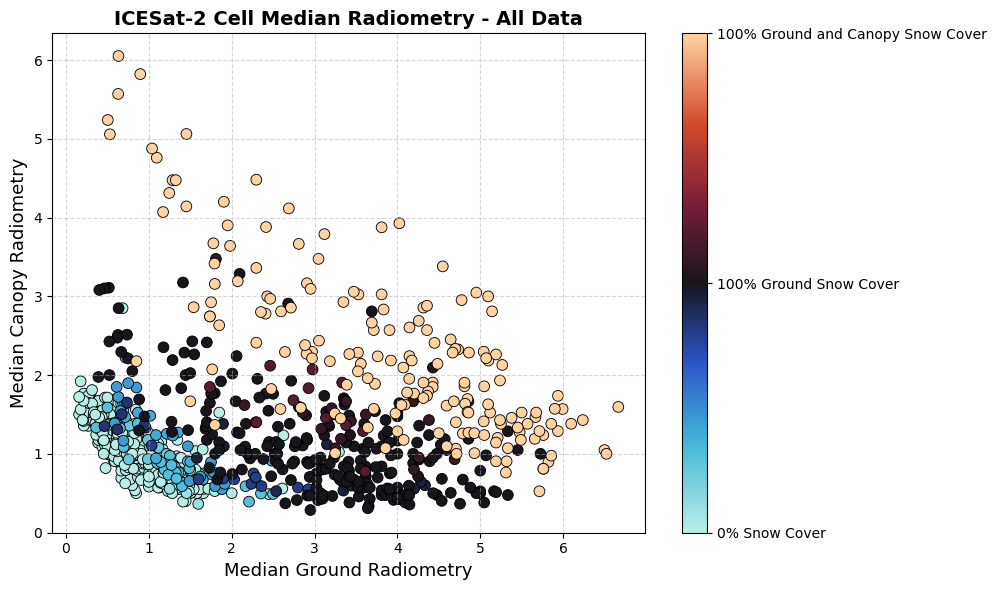

Partial JointSnow data, 0 < JointSnow < 1: 109


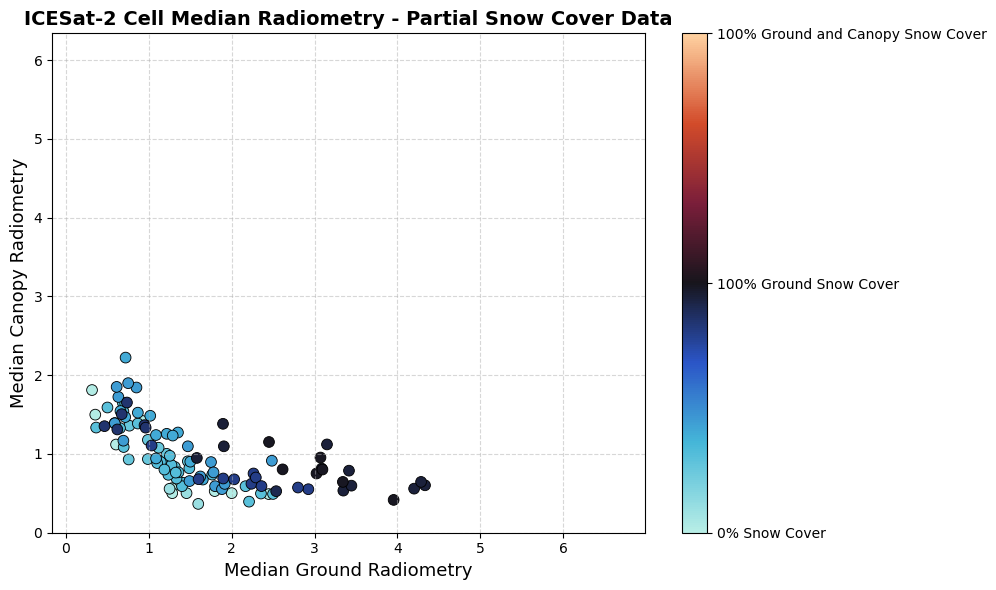

In [4]:
print(f"All filtered data: {len(frac_data)}")
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------
# Shared plotting settings
# ------------------------------------------------------------
# cmap = sns.color_palette("icefire", as_cmap=True)
cmap = LinearSegmentedColormap.from_list(
    "stronger_partial_icefire",
    [
        (0.00, "#b8eee6"),  # 0: pale cyan, snow-free
        (0.18, "#45b6d8"),  # stronger blue transition
        (0.34, "#2b55c7"),  # saturated blue
        (0.50, "#17151c"),  # 1: near black, full ground snow
        (0.66, "#7a1e3a"),  # red-purple
        (0.82, "#d24b2a"),  # orange-red
        (1.00, "#ffd2a1"),  # 2: pale orange, ground + canopy snow
    ]
)
norm = plt.Normalize(0, 2)

xlim = (
    frac_data['Eg_strong'].min(),
    frac_data['Eg_strong'].max()
)

ylim = (
    frac_data['Ev_strong'].min(),
    frac_data['Ev_strong'].max()
)

# Optional small padding so points are not tight against the edge
xpad = 0.05 * (xlim[1] - xlim[0])
ypad = 0.05 * (ylim[1] - ylim[0])

xlim = (xlim[0] - xpad, xlim[1] + xpad)
ylim = (ylim[0] - ypad, ylim[1] + ypad)

# ------------------------------------------------------------
# Plot 1: all filtered data
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.scatterplot(
    data=frac_data.sort_values('JointSnow'),
    x='Eg_strong',
    y='Ev_strong',
    hue='JointSnow',
    palette=cmap,
    hue_norm=norm,
    edgecolor='black',
    s=60,
    ax=ax,
    legend=False
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels([
    '0% Snow Cover',
    '100% Ground Snow Cover',
    '100% Ground and Canopy Snow Cover'
])

ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.xlabel('Median Ground Radiometry', fontsize=13)
plt.ylabel('Median Canopy Radiometry', fontsize=13)
plt.title('ICESat-2 Cell Median Radiometry - All Data', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2: only partial JointSnow, 0 < JointSnow < 1
# ------------------------------------------------------------
partial_data = frac_data[
    (frac_data['JointSnow'] > 0) &
    (frac_data['JointSnow'] < 1)
].copy()

print(f"Partial JointSnow data, 0 < JointSnow < 1: {len(partial_data)}")

plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.scatterplot(
    data=partial_data.sort_values('JointSnow'),
    x='Eg_strong',
    y='Ev_strong',
    hue='JointSnow',
    palette=cmap,
    hue_norm=norm,
    edgecolor='black',
    s=60,
    ax=ax,
    legend=False
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels([
    '0% Snow Cover',
    '100% Ground Snow Cover',
    '100% Ground and Canopy Snow Cover'
])

ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.xlabel('Median Ground Radiometry', fontsize=13)
plt.ylabel('Median Canopy Radiometry', fontsize=13)
plt.title('ICESat-2 Cell Median Radiometry - Partial Snow Cover Data', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

All filtered data: 1123
Partial JointSnow data at selected sites, 0 < JointSnow < 1: 57

Number of partial-snow points per site:
camera
bartlett           6
marcell_MN         3
old_jack_pine     18
underc            13
sodankyla_full     1
hyytiala           1
kenttarova        15
Name: count, dtype: int64


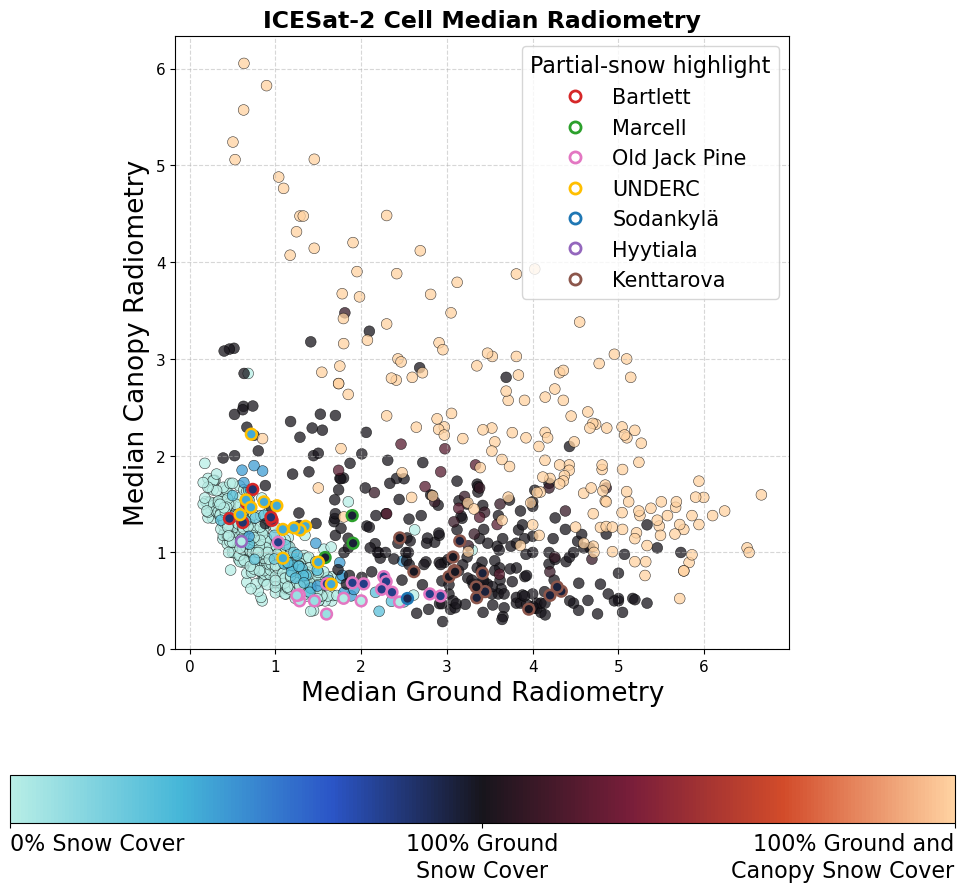

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

print(f"All filtered data: {len(frac_data)}")

# Shared plotting settings
cmap = LinearSegmentedColormap.from_list(
    "stronger_partial_icefire",
    [
        (0.00, "#b8eee6"),
        (0.18, "#45b6d8"),
        (0.34, "#2b55c7"),
        (0.50, "#17151c"),
        (0.66, "#7a1e3a"),
        (0.82, "#d24b2a"),
        (1.00, "#ffd2a1"),
    ]
)
norm = plt.Normalize(0, 2)

xlim = (frac_data['Eg_strong'].min(), frac_data['Eg_strong'].max())
ylim = (frac_data['Ev_strong'].min(), frac_data['Ev_strong'].max())
xpad = 0.05 * (xlim[1] - xlim[0])
ypad = 0.05 * (ylim[1] - ylim[0])
xlim = (xlim[0] - xpad, xlim[1] + xpad)
ylim = (ylim[0] - ypad, ylim[1] + ypad)

# Selected sites and outline colours
selected_sites = [
    'bartlett', 'marcell_MN', 'old_jack_pine', 'underc',
    'sodankyla_full', 'hyytiala', 'kenttarova'
]
site_colours = {
    'bartlett': '#d62728',
    'marcell_MN': '#2ca02c',
    'old_jack_pine': '#e377c2',
    'underc': '#ffbf00',
    'sodankyla_full': '#1f77b4',
    'hyytiala': '#9467bd',
    'kenttarova': '#8c564b'
}
site_labels = {
    'bartlett': 'Bartlett',
    'marcell_MN': 'Marcell',
    'old_jack_pine': 'Old Jack Pine',
    'underc': 'UNDERC',
    'sodankyla_full': 'Sodankylä',
    'hyytiala': 'Hyytiala',
    'kenttarova': 'Kenttarova'
}

# Isolate partial-snow points at selected sites
partial_selected = frac_data[
    (frac_data['JointSnow'] > 0) &
    (frac_data['JointSnow'] < 1) &
    (frac_data['camera'].isin(selected_sites))
].copy()

print(f"Partial JointSnow data at selected sites, 0 < JointSnow < 1: {len(partial_selected)}")
print("\nNumber of partial-snow points per site:")
print(partial_selected['camera'].value_counts().reindex(selected_sites, fill_value=0))

# Plot all filtered data
plt.figure(figsize=(10, 9))
ax = plt.gca()
ax.set_box_aspect(1)

sns.scatterplot(
    data=frac_data.sort_values('JointSnow'),
    x='Eg_strong', y='Ev_strong', hue='JointSnow',
    palette=cmap, hue_norm=norm,
    edgecolor='black', linewidth=0.4,
    s=60, alpha=0.75, ax=ax, legend=False
)

# Redraw selected partial-snow points with coloured outlines
for site in selected_sites:
    site_data = partial_selected[
        partial_selected['camera'] == site
    ].sort_values('JointSnow')

    ax.scatter(
        site_data['Eg_strong'], site_data['Ev_strong'],
        c=site_data['JointSnow'], cmap=cmap, norm=norm,
        s=60, edgecolors=site_colours[site], linewidths=1.8,
        alpha=1.0, zorder=10
    )

# Snow-cover colourbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.16, fraction=0.06)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels([
    '0% Snow Cover',
    '100% Ground\nSnow Cover',
    '100% Ground and\nCanopy Snow Cover'
])
cbar.ax.tick_params(axis='x', labelsize=16)  # 15 -> 16

colourbar_labels = cbar.ax.get_xticklabels()
colourbar_labels[0].set_horizontalalignment('left')
colourbar_labels[-1].set_horizontalalignment('right')

# Site legend
site_legend_handles = [
    Line2D(
        [0], [0], marker='o', linestyle='None',
        markerfacecolor='white', markeredgecolor=site_colours[site],
        markeredgewidth=2, markersize=8, label=site_labels[site]
    )
    for site in selected_sites
]
ax.legend(
    handles=site_legend_handles, title='Partial-snow highlight',
    loc='upper right', frameon=True,
    fontsize=15, title_fontsize=16  # 14 -> 15; 15 -> 16
)

# Formatting
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Median Ground Radiometry', fontsize=19)  # 18 -> 19
ax.set_ylabel('Median Canopy Radiometry', fontsize=19)  # 18 -> 19
ax.set_title('ICESat-2 Cell Median Radiometry', fontsize=17, weight='bold')  # 16 -> 17
ax.grid(True, linestyle='--', alpha=0.5)

# Increase the inherited axis tick sizes by one point as well.
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(label.get_fontsize() + 1)
for axis in (ax.xaxis, ax.yaxis, cbar.ax.xaxis, cbar.ax.yaxis):
    offset_text = axis.get_offset_text()
    offset_text.set_fontsize(offset_text.get_fontsize() + 1)

plt.tight_layout()
plt.show()


All filtered data: 1123
0% snow-cover data at selected sites, JointSnow == 0: 187

Number of 0%-snow points per site:
camera
underhill        5
willowcreek     33
torgnon          1
glees           14
oregon_yp      134
Name: count, dtype: int64


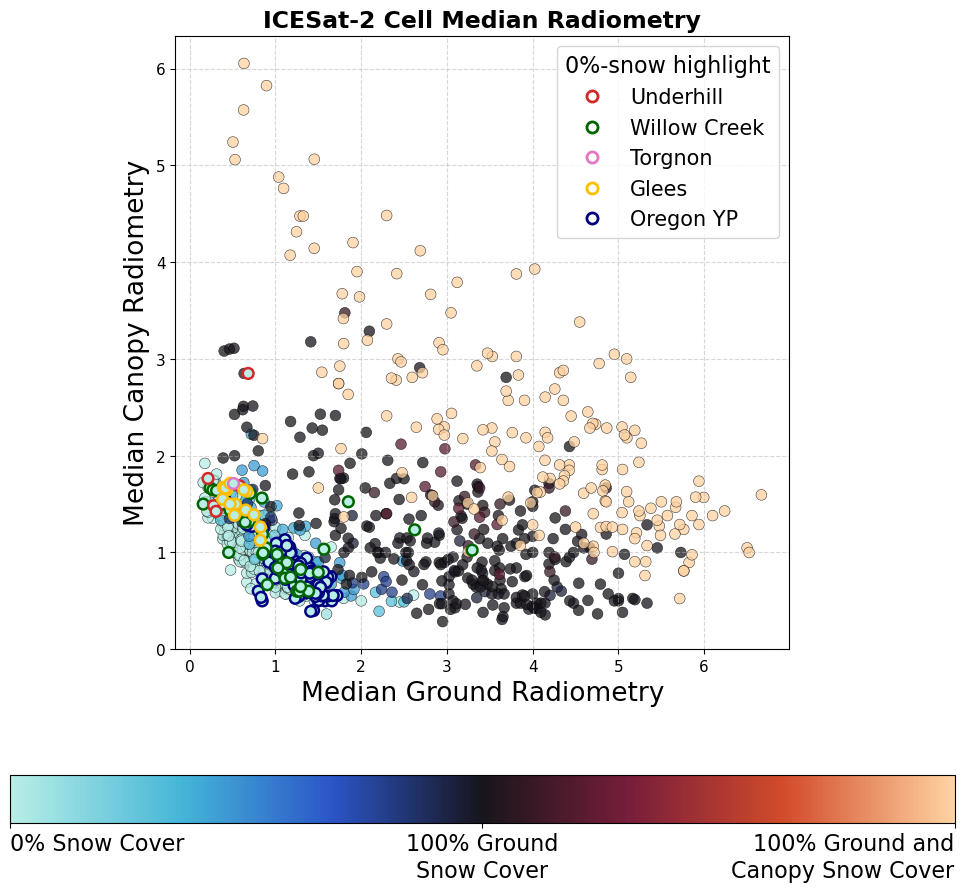

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

print(f"All filtered data: {len(frac_data)}")

# Shared plotting settings
cmap = LinearSegmentedColormap.from_list(
    "stronger_partial_icefire",
    [
        (0.00, "#b8eee6"),
        (0.18, "#45b6d8"),
        (0.34, "#2b55c7"),
        (0.50, "#17151c"),
        (0.66, "#7a1e3a"),
        (0.82, "#d24b2a"),
        (1.00, "#ffd2a1"),
    ]
)
norm = plt.Normalize(0, 2)

xlim = (frac_data['Eg_strong'].min(), frac_data['Eg_strong'].max())
ylim = (frac_data['Ev_strong'].min(), frac_data['Ev_strong'].max())
xpad = 0.05 * (xlim[1] - xlim[0])
ypad = 0.05 * (ylim[1] - ylim[0])
xlim = (xlim[0] - xpad, xlim[1] + xpad)
ylim = (ylim[0] - ypad, ylim[1] + ypad)

# Selected sites and outline colours
selected_sites = ['underhill', 'willowcreek', 'torgnon', 'glees', 'oregon_yp']
site_colours = {
    'underhill': '#d62728',
    'willowcreek': '#006400',
    'torgnon': '#e377c2',
    'glees': '#ffbf00',
    'oregon_yp': '#000080'
}
site_labels = {
    'underhill': 'Underhill',
    'willowcreek': 'Willow Creek',
    'torgnon': 'Torgnon',
    'glees': 'Glees',
    'oregon_yp': 'Oregon YP'
}

# Willow Creek is behind Underhill, Glees, and Torgnon.
# Torgnon is drawn last so its single point is on top.
highlight_order = ['oregon_yp', 'willowcreek', 'underhill', 'glees', 'torgnon']

# Isolate 0% snow-cover points at selected sites
zero_selected = frac_data[
    np.isclose(frac_data['JointSnow'], 0) &
    (frac_data['camera'].isin(selected_sites))
].copy()

print(f"0% snow-cover data at selected sites, JointSnow == 0: {len(zero_selected)}")
print("\nNumber of 0%-snow points per site:")
print(zero_selected['camera'].value_counts().reindex(selected_sites, fill_value=0))

# Plot all filtered data
plt.figure(figsize=(10, 9))
ax = plt.gca()
ax.set_box_aspect(1)

sns.scatterplot(
    data=frac_data.sort_values('JointSnow'),
    x='Eg_strong', y='Ev_strong', hue='JointSnow',
    palette=cmap, hue_norm=norm,
    edgecolor='black', linewidth=0.4,
    s=60, alpha=0.75, ax=ax, legend=False
)

# Redraw selected 0%-snow points with coloured outlines
for i, site in enumerate(highlight_order):
    site_data = zero_selected[
        zero_selected['camera'] == site
    ].sort_values('JointSnow')

    ax.scatter(
        site_data['Eg_strong'], site_data['Ev_strong'],
        c=site_data['JointSnow'], cmap=cmap, norm=norm,
        s=60, edgecolors=site_colours[site], linewidths=1.8,
        alpha=1.0, zorder=10 + i
    )

# Snow-cover colourbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.16, fraction=0.06)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels([
    '0% Snow Cover',
    '100% Ground\nSnow Cover',
    '100% Ground and\nCanopy Snow Cover'
])
cbar.ax.tick_params(axis='x', labelsize=16)  # 15 -> 16

colourbar_labels = cbar.ax.get_xticklabels()
colourbar_labels[0].set_horizontalalignment('left')
colourbar_labels[-1].set_horizontalalignment('right')

# Site legend
site_legend_handles = [
    Line2D(
        [0], [0], marker='o', linestyle='None',
        markerfacecolor='white', markeredgecolor=site_colours[site],
        markeredgewidth=2, markersize=8, label=site_labels[site]
    )
    for site in selected_sites
]
ax.legend(
    handles=site_legend_handles, title='0%-snow highlight',
    loc='upper right', frameon=True,
    fontsize=15, title_fontsize=16  # 14 -> 15; 15 -> 16
)

# Formatting
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Median Ground Radiometry', fontsize=19)  # 18 -> 19
ax.set_ylabel('Median Canopy Radiometry', fontsize=19)  # 18 -> 19
ax.set_title('ICESat-2 Cell Median Radiometry', fontsize=17, weight='bold')  # 16 -> 17
ax.grid(True, linestyle='--', alpha=0.5)

# Increase the inherited axis tick sizes by one point as well.
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(label.get_fontsize() + 1)
for axis in (ax.xaxis, ax.yaxis, cbar.ax.xaxis, cbar.ax.yaxis):
    offset_text = axis.get_offset_text()
    offset_text.set_fontsize(offset_text.get_fontsize() + 1)

plt.tight_layout()
plt.show()


All filtered data: 1123
100% ground snow-covered data at selected sites, JointSnow == 1: 47

Number of 100%-snow points per site:
camera
willowcreek    19
hyytiala       14
bartlett       14
Name: count, dtype: int64


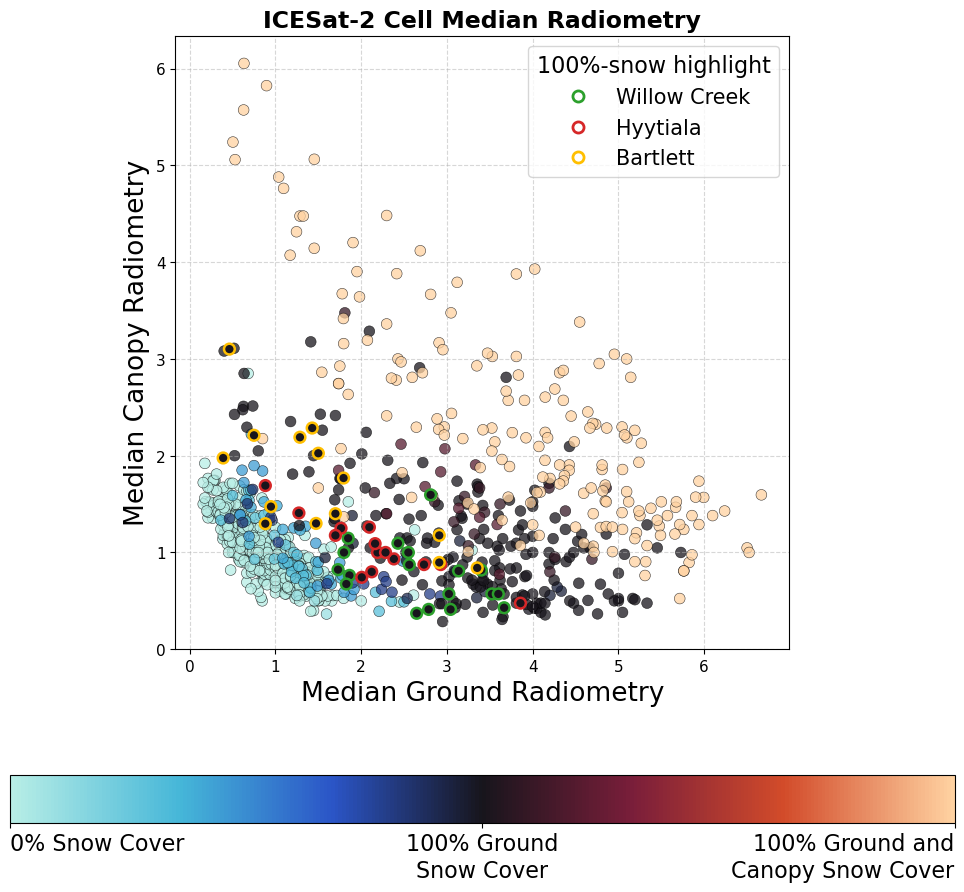

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

print(f"All filtered data: {len(frac_data)}")

# Shared plotting settings
cmap = LinearSegmentedColormap.from_list(
    "stronger_partial_icefire",
    [
        (0.00, "#b8eee6"),
        (0.18, "#45b6d8"),
        (0.34, "#2b55c7"),
        (0.50, "#17151c"),
        (0.66, "#7a1e3a"),
        (0.82, "#d24b2a"),
        (1.00, "#ffd2a1"),
    ]
)
norm = plt.Normalize(0, 2)

xlim = (frac_data['Eg_strong'].min(), frac_data['Eg_strong'].max())
ylim = (frac_data['Ev_strong'].min(), frac_data['Ev_strong'].max())
xpad = 0.05 * (xlim[1] - xlim[0])
ypad = 0.05 * (ylim[1] - ylim[0])
xlim = (xlim[0] - xpad, xlim[1] + xpad)
ylim = (ylim[0] - ypad, ylim[1] + ypad)

# Selected sites and outline colours
selected_sites = ['willowcreek', 'hyytiala', 'bartlett']
site_colours = {
    'willowcreek': '#2ca02c',
    'hyytiala': '#d62728',
    'bartlett': '#ffbf00'
}
site_labels = {
    'willowcreek': 'Willow Creek',
    'hyytiala': 'Hyytiala',
    'bartlett': 'Bartlett'
}

# Bartlett is plotted last and appears on top wherever points overlap.
highlight_order = ['willowcreek', 'hyytiala', 'bartlett']

# Isolate 100% ground snow-covered points at selected sites.
full_snow_selected = frac_data[
    np.isclose(frac_data['JointSnow'], 1) &
    (frac_data['camera'].isin(selected_sites))
].copy()

print(f"100% ground snow-covered data at selected sites, JointSnow == 1: {len(full_snow_selected)}")
print("\nNumber of 100%-snow points per site:")
print(full_snow_selected['camera'].value_counts().reindex(selected_sites, fill_value=0))

# Plot all filtered data
plt.figure(figsize=(10, 9))
ax = plt.gca()
ax.set_box_aspect(1)

sns.scatterplot(
    data=frac_data.sort_values('JointSnow'),
    x='Eg_strong', y='Ev_strong', hue='JointSnow',
    palette=cmap, hue_norm=norm,
    edgecolor='black', linewidth=0.4,
    s=60, alpha=0.75, ax=ax, legend=False
)

# Redraw selected 100%-snow points with coloured outlines
for i, site in enumerate(highlight_order):
    site_data = full_snow_selected[
        full_snow_selected['camera'] == site
    ]

    ax.scatter(
        site_data['Eg_strong'], site_data['Ev_strong'],
        c=site_data['JointSnow'], cmap=cmap, norm=norm,
        s=60, edgecolors=site_colours[site], linewidths=1.8,
        alpha=1.0, zorder=10 + i
    )

# Snow-cover colourbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.16, fraction=0.06)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels([
    '0% Snow Cover',
    '100% Ground\nSnow Cover',
    '100% Ground and\nCanopy Snow Cover'
])
cbar.ax.tick_params(axis='x', labelsize=16)  # 15 -> 16

colourbar_labels = cbar.ax.get_xticklabels()
colourbar_labels[0].set_horizontalalignment('left')
colourbar_labels[-1].set_horizontalalignment('right')

# Site legend
site_legend_handles = [
    Line2D(
        [0], [0], marker='o', linestyle='None',
        markerfacecolor='white', markeredgecolor=site_colours[site],
        markeredgewidth=2, markersize=8, label=site_labels[site]
    )
    for site in selected_sites
]
ax.legend(
    handles=site_legend_handles, title='100%-snow highlight',
    loc='upper right', frameon=True,
    fontsize=15, title_fontsize=16  # 14 -> 15; 15 -> 16
)

# Formatting
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel('Median Ground Radiometry', fontsize=19)  # 18 -> 19
ax.set_ylabel('Median Canopy Radiometry', fontsize=19)  # 18 -> 19
ax.set_title('ICESat-2 Cell Median Radiometry', fontsize=17, weight='bold')  # 16 -> 17
ax.grid(True, linestyle='--', alpha=0.5)

# Increase the inherited axis tick sizes by one point as well.
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(label.get_fontsize() + 1)
for axis in (ax.xaxis, ax.yaxis, cbar.ax.xaxis, cbar.ax.yaxis):
    offset_text = axis.get_offset_text()
    offset_text.set_fontsize(offset_text.get_fontsize() + 1)

plt.tight_layout()
plt.show()
